## Obróbka zdjęć z biblioteką PIL

Python Imaging Library (PIL) jest  pakietem do przetwarzania obrazów dla języka Python. Zawiera narzędzia do przetwarzania obrazu, które pomagają w edycji, tworzeniu i zapisywaniu obrazów.  Biblioteka Pillow jest zbudowana na PIL. Pillow obsługuje wiele formatów plików graficznych, w tym BMP, PNG, JPEG i TIFF.

In [1]:
import os
os.chdir("/content")

In [2]:
from PIL import Image

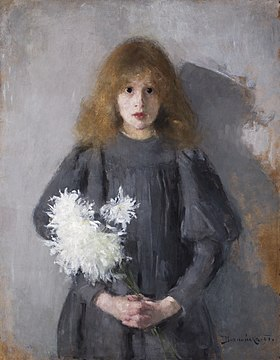

In [3]:
Ola=Image.open('Olga.jpg')
Ola

In [4]:
r, g, b =Ola.split()

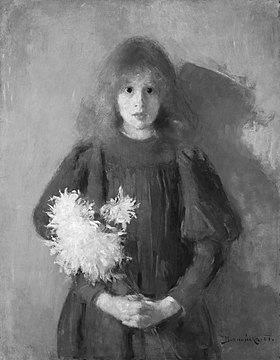

In [5]:
r

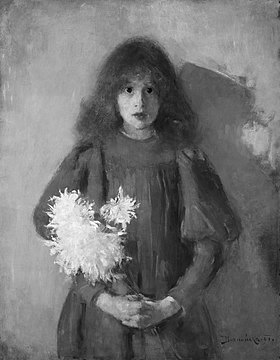

In [6]:
b

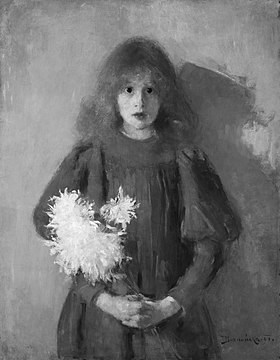

In [7]:
g

In [8]:
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
transform = transforms.ToTensor()
image_tensor = transform(Ola)

# Szczegóły
print(f"Kształt tensora {image_tensor.shape}")
print(f"Typ danych: {image_tensor.dtype}")
image_tensor

Kształt tensora torch.Size([3, 360, 280])
Typ danych: torch.float32


tensor([[[0.5137, 0.4980, 0.4980,  ..., 0.5529, 0.4980, 0.4588],
         [0.4627, 0.5059, 0.5373,  ..., 0.5961, 0.5176, 0.2196],
         [0.4902, 0.5333, 0.5569,  ..., 0.6196, 0.5216, 0.1490],
         ...,
         [0.6588, 0.7020, 0.5961,  ..., 0.2980, 0.2980, 0.1725],
         [0.5922, 0.6118, 0.5412,  ..., 0.3490, 0.3529, 0.2588],
         [0.6000, 0.5647, 0.5255,  ..., 0.3647, 0.3804, 0.3843]],

        [[0.4627, 0.4471, 0.4471,  ..., 0.4980, 0.4431, 0.4039],
         [0.4118, 0.4549, 0.4863,  ..., 0.5412, 0.4627, 0.1647],
         [0.4353, 0.4784, 0.5059,  ..., 0.5647, 0.4627, 0.0902],
         ...,
         [0.5098, 0.5529, 0.4549,  ..., 0.2549, 0.2549, 0.1294],
         [0.4392, 0.4627, 0.4000,  ..., 0.2941, 0.2980, 0.2039],
         [0.4471, 0.4157, 0.3765,  ..., 0.3098, 0.3255, 0.3294]],

        [[0.4000, 0.3843, 0.3843,  ..., 0.4863, 0.4314, 0.3922],
         [0.3490, 0.3922, 0.4235,  ..., 0.5294, 0.4510, 0.1529],
         [0.3843, 0.4275, 0.4431,  ..., 0.5529, 0.4431, 0.

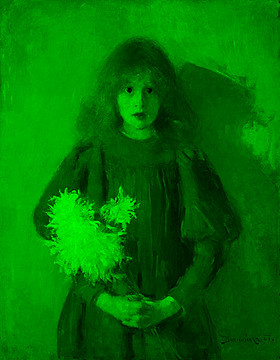

In [32]:
black = Image.new('L', Ola.size)

red_image = Image.merge('RGB', (r, black, black))
green_image = Image.merge('RGB', (black, g, black))
blue_image = Image.merge('RGB', (black, black, b))
zloty_image = Image.merge('RGB', (r, g, black))
pink_image = Image.merge('RGB', (r, black, b))
green_image

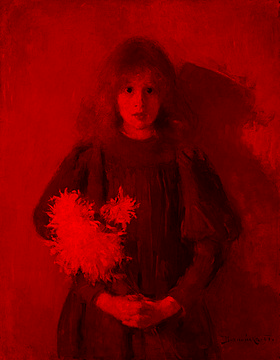

In [10]:
red_image

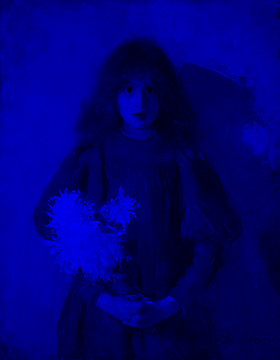

In [11]:
blue_image


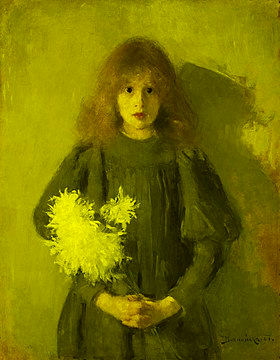

In [26]:
zloty_image

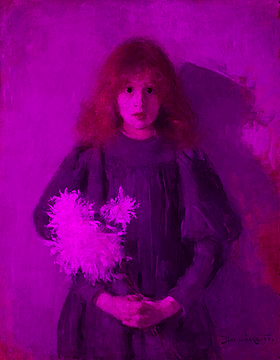

In [33]:
pink_image

In [12]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
import skimage.feature
import sys

filename = 'Olga.jpg'  # Wprowadź swoją ścieżkę
sigma = 2.0
low_threshold = 0.1
high_threshold = 0.2

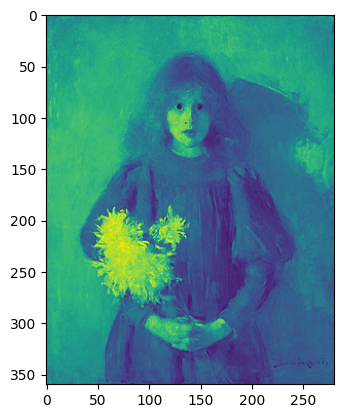

In [13]:
image = iio.imread('Olga.jpg', mode="L")
plt.imshow(image)

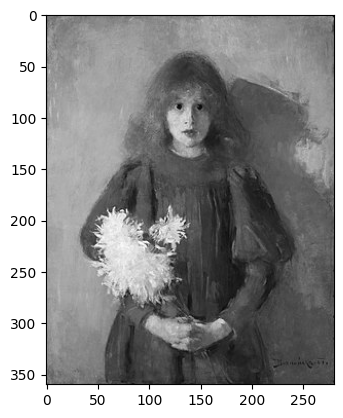

In [14]:
plt.imshow(image.squeeze(), cmap="gray")

(280, 360)
(78, 100)


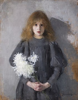

In [15]:
# zmniejszenie obrazu
from PIL import Image
# load the image
image = Image.open('Olga.jpg')
# report the size of the image
print(image.size)
# create a thumbnail and preserve aspect ratio
image.thumbnail((100,100))
# report the size of the modified image
print(image.size)
# show the image
image

(280, 360)
(200, 200)


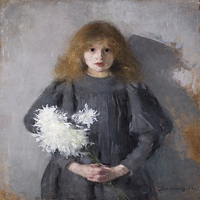

In [16]:
from PIL import Image
# load the image
image = Image.open('Olga.jpg')
# resize image and force a new shape
print(image.size)
# resize image and ignore original aspect ratio
img_resized = image.resize((200,200))
# report the size of the thumbnail
print(img_resized.size)
# show the image
img_resized

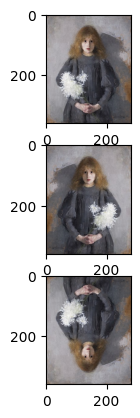

In [17]:
from PIL import Image
from matplotlib import pyplot
# load the image
image = Image.open('Olga.jpg')
hoz_flip = image.transpose(Image.FLIP_LEFT_RIGHT)
# odwrócenie pionowe
ver_flip = image.transpose(Image.FLIP_TOP_BOTTOM)
# wykreślić wszystkie trzy obrazy przy użyciu matplotlib
pyplot.subplot(311)
pyplot.imshow(image)
pyplot.subplot(312)
pyplot.imshow(hoz_flip)
pyplot.subplot(313)
pyplot.imshow(ver_flip)
pyplot.show()

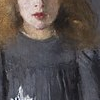

In [18]:
# kadrowanie obrazu
from PIL import Image
# load image
image = Image.open('Olga.jpg')
# create a cropped image
cropped = image.crop((100, 100, 200, 200))
# show cropped image
cropped

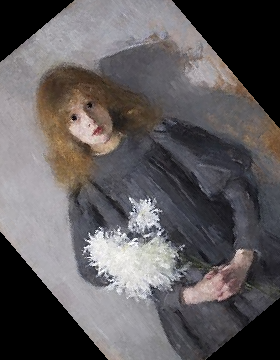

In [19]:
from PIL import Image
 #rotacja obrazu
angle = 40
image = Image.open('Olga.jpg')
r_image = image.rotate(angle)
r_image

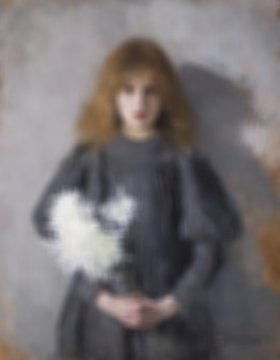

In [20]:

# Importing Image class from PIL module
from PIL import Image, ImageFilter

# Opens a image in RGB mode
image = Image.open('Olga.jpg')

# Rozmycie obrazu
imageB = image.filter(ImageFilter.BoxBlur(4))

# Podgląd
imageB


[Więcej na Geeksforgeeks](https://www.geeksforgeeks.org/python-pillow-blur-an-image/?ref=lbp)

In [21]:
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
transform = transforms.ToTensor()
image_tensor = transform(Ola)

In [39]:
# Image Classification
import torch
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.6),
    v2.Grayscale(),
    v2.RandomRotation(degrees=(0,90)),
])
img = transforms(image_tensor)
img.shape
img.shape

torch.Size([1, 224, 224])

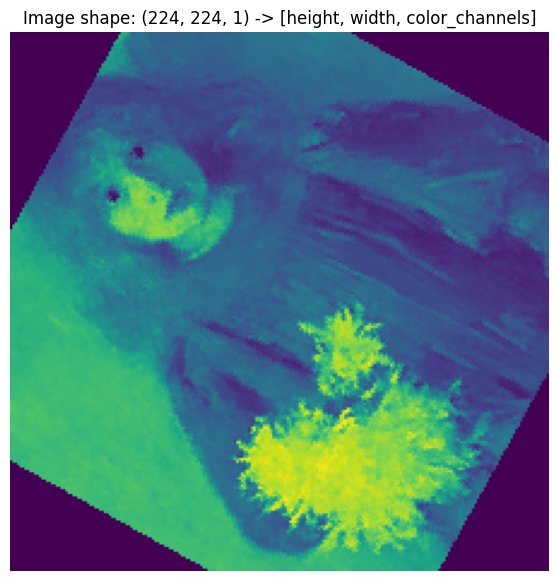

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Przekształcenie zdjęcia na np array (tablicę numpy)
img_as_array = np.asarray(img)
img_as_array = img_as_array.transpose(1, 2, 0) # Change the order of dimensions

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image shape: {img_as_array.shape} -> [height, width, color_channels]") #Removed image_class as it was not defined
plt.axis(False);


In [24]:
# Image Classification
import torch
from torchvision.transforms import v2

transforms = v2.Compose([

    v2.RandomHorizontalFlip(p=0.5),
    v2.Grayscale()
])
image = transforms(image_tensor)
image


tensor([[[0.4708, 0.4551, 0.4551,  ..., 0.5131, 0.4582, 0.4190],
         [0.4198, 0.4629, 0.4943,  ..., 0.5562, 0.4778, 0.1798],
         [0.4458, 0.4890, 0.5139,  ..., 0.5797, 0.4780, 0.1055],
         ...,
         [0.5378, 0.5809, 0.4810,  ..., 0.2660, 0.2660, 0.1405],
         [0.4675, 0.4907, 0.4261,  ..., 0.3092, 0.3131, 0.2190],
         [0.4753, 0.4428, 0.4049,  ..., 0.3248, 0.3405, 0.3444]]])

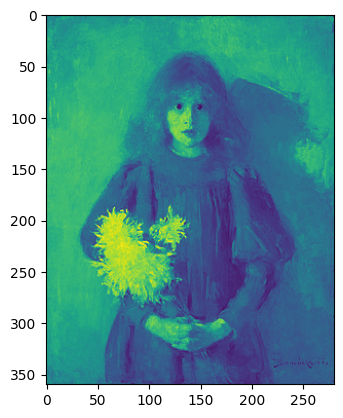

In [25]:
import numpy as np
out_img=image.detach().numpy()
obraz = np.squeeze(out_img)
plt.imshow(obraz)
